## 訓練データの作成

In [38]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.font_manager
import numpy as np
import random
import matplotlib.pyplot as plt
import cv2

font_pathes = [
    "/System/Library/Fonts/Supplemental/Arial.ttf",
    "/System/Library/Fonts/Supplemental/Times New Roman.ttf",
    "/System/Library/Fonts/Supplemental/Trattatello.ttf",
    "/Users/yuonoda/Library/Fonts/NotoSans-BoldItalic.ttf",
    "/Users/yuonoda/Library/Fonts/NotoSans-Bold.ttf",
    "/Users/yuonoda/Library/Fonts/NotoSans-Italic.ttf",
]
print("variation patterns=", len(font_pathes))

# 利用するフォントサイズをパターン指定
font_sizes = range(50, 100, 2)
# font_sizes = [50]
print("sizes patterns =", len(font_sizes))

# 生成した画像とラベルを格納するリスト
images = []
labels = []

# 各フォントに対して
NOISE_PATTERN_NUM = 7
for font_path in font_pathes:
    
    # 各フォントサイズに対して
    for font_size in font_sizes:
        try:
            # フォントオブジェクトを作成
            font = ImageFont.truetype(font_path, size=font_size)
        except IOError:
            continue  # エラーが起きた場合、このフォントはスキップします

        # 数字0-9を描画
        for number in range(10):
            # 0の場合、背景画像を使う
            if number == 0:
                # リサイズ、グレースケール
                image = Image.new('RGB', (100, 100), (248, 250, 255))
                image = image.resize((60, 60))
                np_image = np.array(image)
                np_image = cv2.cvtColor(np_image, cv2.COLOR_RGB2GRAY)
                
                # 画像とラベルを保存
                images.append(np_image)
                labels.append(number)
                continue
            
            # 1-9のときは、ノイズを加えてデータを増やす
            for _ in range(NOISE_PATTERN_NUM):    

                # 新しい画像オブジェクトを生成
                image = Image.new('RGB', (100, 100), (248, 250, 255))
                # image = Image.new('L', (100, 100), 255)
                draw = ImageDraw.Draw(image)
                # draw = ImageDraw.Draw(image.copy())
    
                # 位置ノイズを作成
                x_noise = random.randint(-18, 18)
                y_noise = random.randint(-15, 15)
                
                # 数字を中央付近に描画
                text = str(number)
                text_width, text_height = draw.textsize(text, font=font)
                x = (image.width - text_width) // 2 + x_noise
                y = (image.height - text_height) // 2 + y_noise
                draw.text((x, y), text, font=font, fill=0)

                #リサイズ
                image = image.resize((60, 60))
                
                # グレースケールに変換
                np_image = np.array(image)
                np_image = cv2.cvtColor(np_image, cv2.COLOR_RGB2GRAY)
                
                # 画像とラベルを保存
                images.append(np_image)
                labels.append(number)
            

print("total images =", len(images))


variation patterns= 6
sizes patterns = 25


/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_1314/4267971038.py:69: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_1314/4267971038.py:69: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_1314/4267971038.py:69: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_1314/4267971038.py:69: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength 

total images = 9600


/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_1314/4267971038.py:69: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_1314/4267971038.py:69: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_1314/4267971038.py:69: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_1314/4267971038.py:69: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength 

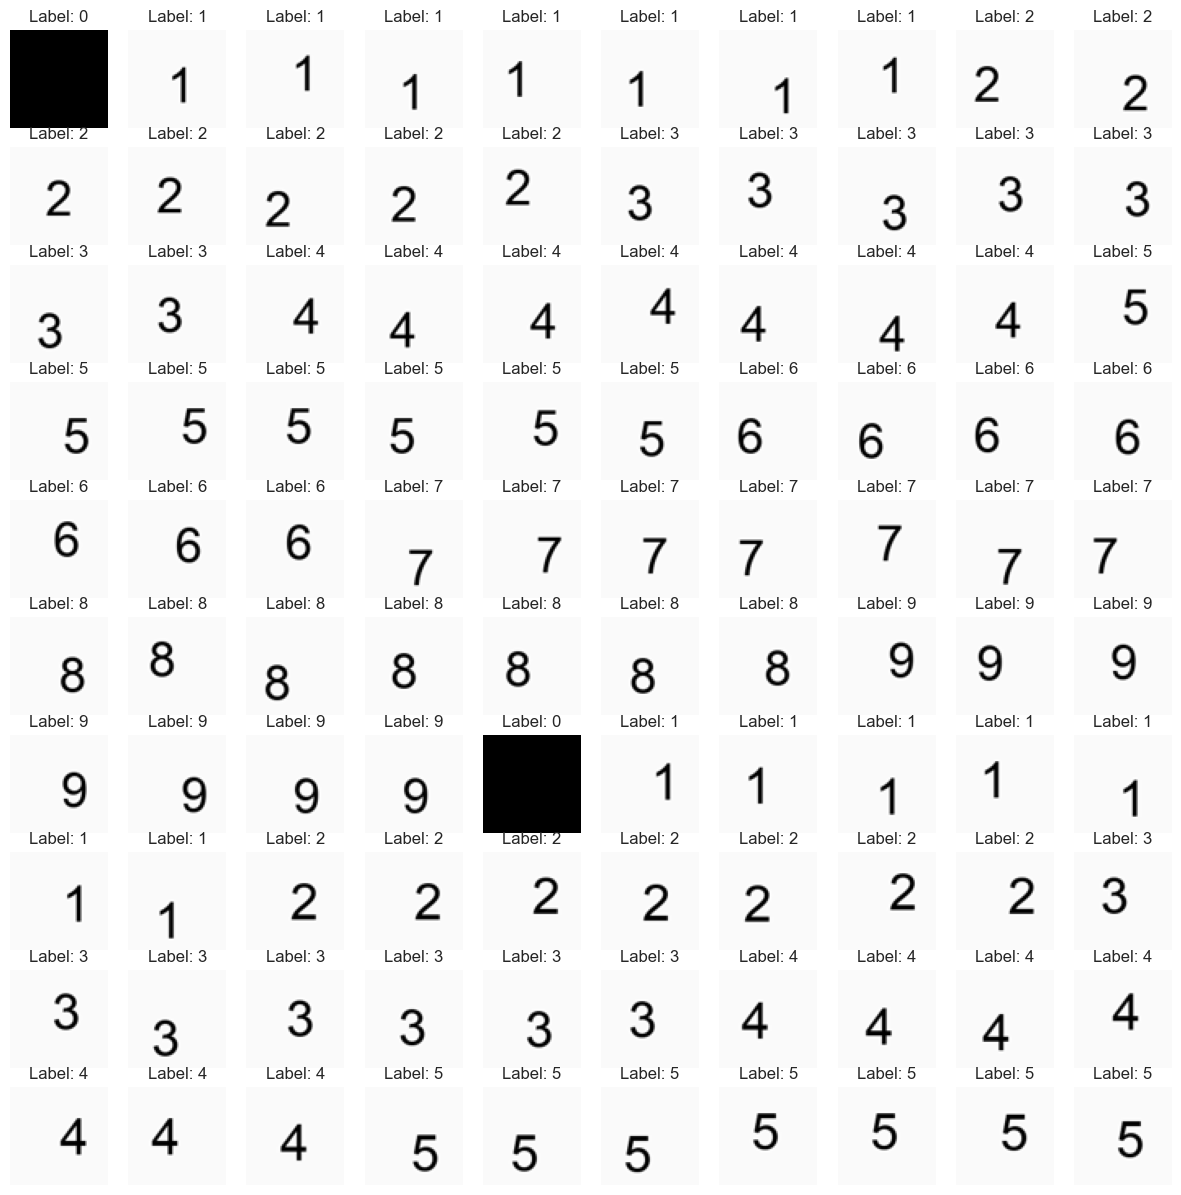

In [39]:
import matplotlib.pyplot as plt
import math

# イメージの合計枚数を取得
images_to_show =random.sample(images, 100) # ランダムに100個取得
# images_to_show = images
total_images = len(images_to_show)

# グリッドのサイズを計算 (例: 20x10)
cols = 10   
rows = math.ceil(total_images / cols)  # 必要な行数を計算

# 画像とラベルを表示
fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
for idx, ax in enumerate(axes.flatten()):
    if idx < total_images:
        ax.imshow(images[idx], cmap='gray')
        ax.set_title(f"Label: {labels[idx]}")
    ax.axis('off')  # 軸を非表示に
plt.show()

In [40]:
# numpy配列に変換
images = np.array(images)
labels = np.array(labels)

# .npz形式で保存
x_reshaped = images.reshape((images.shape[0], -1))
np.savez("../images_and_labels.npz", x=x_reshaped, y=labels)


## 画像マスの抽出

In [41]:
import cv2
filepath = "../data/level1/sudoku_028"
# filepath = "../data/level1/sample"
imgname = filepath + ".jpg"
img = cv2.imread(imgname, cv2.IMREAD_COLOR)
if img is None:
    raise IOError("Faileld to load image: {:s}".format(filepath))

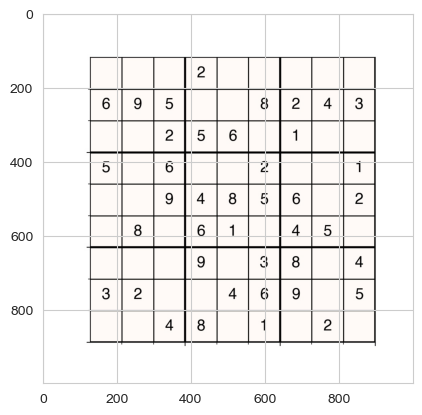

In [42]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

In [43]:
import cv2
import numpy as np

# 二値データに変換
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

# 輪郭を見つける
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(largest_contour)

# 各マス目の画像を抽出し、リストに保存
cell_images = []
stepx = w // 9
stepy = h // 9
trim_size_x = stepx // 7
trim_size_y = stepy // 7
EMPTY_THRESHOLD = 200
for i in range(9):
    for j in range(9):
        cell = gray[y + i*stepy + trim_size_y : y + (i+1)*stepy - trim_size_y,
               x + j*stepx + trim_size_x : x + (j+1)*stepx - trim_size_x]
        resized_cell = cv2.resize(cell, (60, 60), interpolation=cv2.INTER_CUBIC)
        normalized = resized_cell / 255.0
        cell_images.append(normalized)

In [44]:
print(cell_images[0])
print(np.unique(cell_images[0]))

[[0.98039216 0.98039216 0.98039216 ... 0.98039216 0.98039216 0.98039216]
 [0.98039216 0.98039216 0.98039216 ... 0.98039216 0.98039216 0.98039216]
 [0.98039216 0.98039216 0.98039216 ... 0.98039216 0.98039216 0.98039216]
 ...
 [0.98039216 0.98039216 0.98039216 ... 0.98039216 0.98039216 0.98039216]
 [0.98039216 0.98039216 0.98039216 ... 0.98039216 0.98039216 0.98039216]
 [0.98039216 0.98039216 0.98039216 ... 0.98039216 0.98039216 0.98039216]]
[0.98039216]


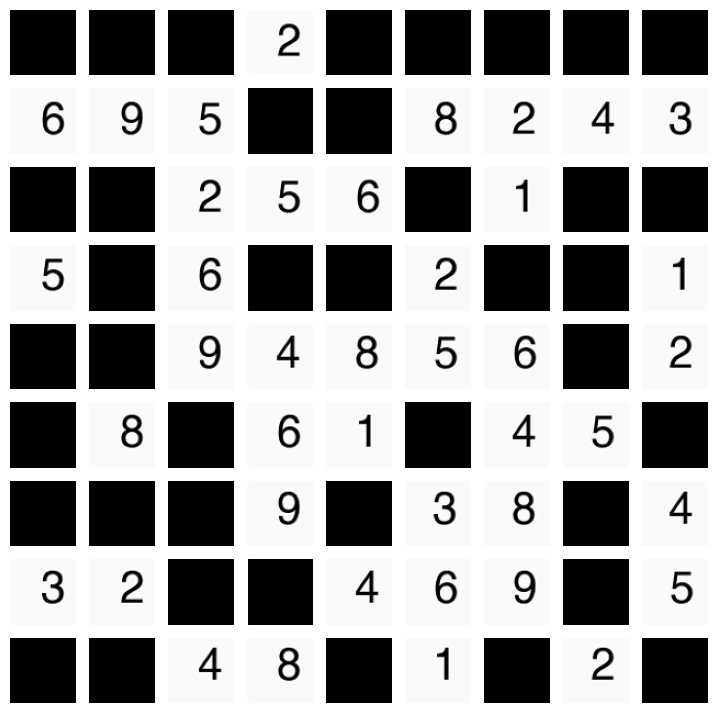

In [45]:
import matplotlib.pyplot as plt

## 抽出結果の可視化

# 9x9のグリッドを作り、各セルに画像をプロット
fig, axs = plt.subplots(9, 9, figsize=(9, 9))
axs = axs.flatten()

# 各軸（ax）について画像をプロット
for ax, cell in zip(axs, cell_images):
    ax.imshow(cell, cmap="gray") # BGRからRGBへ変換
    ax.axis('off')  # 軸の情報をオフにする

plt.show()


## 数字の学習

In [46]:
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split

# データ読み込み
# photos = np.load('../28px_10_new.npz')
photos = np.load('../images_and_labels.npz')
x = photos['x']
y = photos['y']
print("len(x)=", len(x))
print(x.shape)
print(y.shape)

# スケーリング
x = x / 255.0

# 訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=1)

len(x)= 9600
(9600, 3600)
(9600,)


In [47]:
# SVMで学習
clf = svm.SVC()
clf.fit(X_train, y_train)

# 訓練データでの精度を確認
acc_train = clf.score(X_train, y_train)
print("SVM CV: acc(train)={:.2f}%".format(acc_train))

SVM CV: acc(train)=0.94%


In [53]:
from sklearn.neighbors import KNeighborsClassifier

# KNNで学習
n_neighbors = 20
clf = KNeighborsClassifier(n_neighbors=n_neighbors)
clf.fit(X_train, y_train)

# 訓練データでの精度を確認
acc_train = clf.score(X_train, y_train)
print("KNN CV: acc(train)={:.2f}%".format(acc_train))

KNN CV: acc(train)=0.83%


In [58]:
from sklearn.linear_model import LogisticRegression

# ロジスティック回帰で学習
lr_params = {"tol": 1.0e-3, "max_iter": 5000, "solver": "lbfgs"}
clf = LogisticRegression(**lr_params)
clf.fit(X_train, y_train)

# 訓練データでの精度を確認
acc_train = clf.score(X_train, y_train)
print("LR CV: acc(train)={:.2f}%".format(acc_train))

LR CV: acc(train)=0.73%


In [54]:
from sklearn import metrics

# 予測の実行
predicted = clf.predict(X_test)
print(f"Classification report for classifier {clf}:\n"
      f"{metrics.classification_report(y_test, predicted)}\n")


Classification report for classifier KNeighborsClassifier(n_neighbors=20):
              precision    recall  f1-score   support

           0       0.35      1.00      0.52        34
           1       0.58      0.96      0.72       208
           2       0.97      0.74      0.84       198
           3       0.79      0.70      0.74       215
           4       0.89      0.78      0.83       225
           5       0.85      0.77      0.81       183
           6       0.91      0.80      0.85       232
           7       0.85      0.88      0.86       212
           8       0.94      0.78      0.85       214
           9       0.97      0.85      0.91       199

    accuracy                           0.81      1920
   macro avg       0.81      0.83      0.79      1920
weighted avg       0.85      0.81      0.82      1920


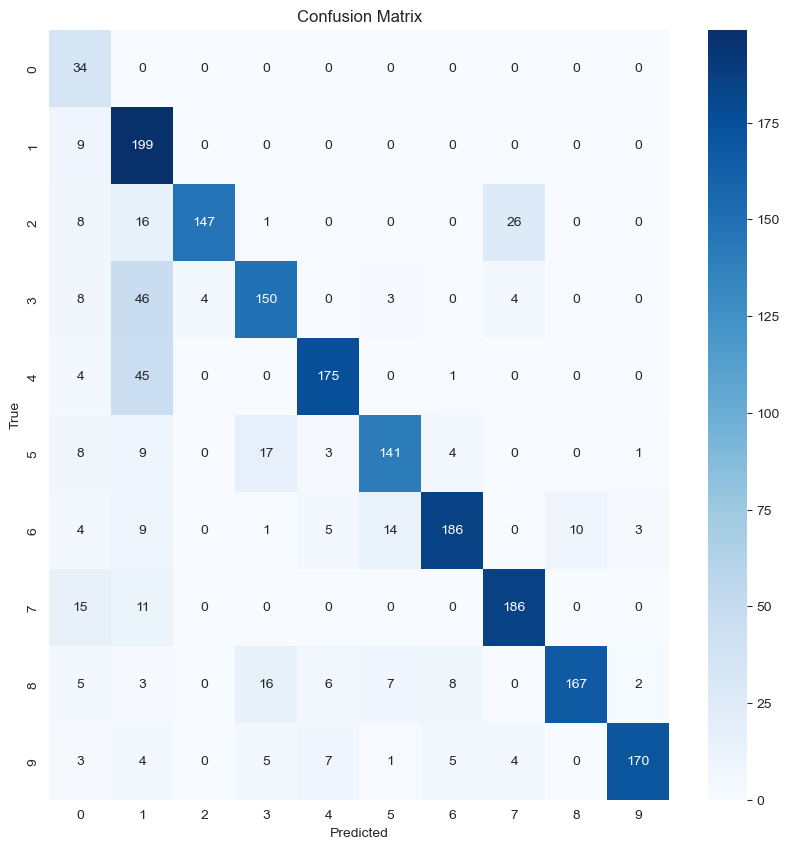

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# 混同行列の可視化
conf_mat = metrics.confusion_matrix(y_test, predicted)
plt.figure(figsize=(10, 10))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# モデルの保存
import pickle
serials = pickle.dumps(clf)
with open("../rbf_svm.pickle", "wb") as f:
    f.write(serials)

In [ ]:
# 再読み込みとテスト
clf2 = None
with open("../rbf_svm.pickle", "rb") as f:
    clf2 = pickle.loads(f.read())

acc_test = clf2.score(X_test, y_test)
print("CV: acc(test)={:.2f}%".format(acc_test))

# 数字予測

In [56]:
# 予測
model_input = np.array(cell_images)
model_input_2d = model_input.reshape(model_input.shape[0], -1)# モデル入力を2次元に変換
predicted = clf.predict(model_input_2d) 

In [57]:
import numpy as np
textname = filepath + ".txt"
correct_labels = correct_labels = np.loadtxt(textname, dtype=int)
correct_labels_flat = correct_labels.flatten()

# Accuracyを計算して表示
accuracy = metrics.accuracy_score(correct_labels_flat, predicted)
print(f"Accuracy: {accuracy:.2f}")

print(metrics.classification_report(correct_labels_flat, predicted))

Accuracy: 0.79
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.44      1.00      0.62         4
           2       1.00      0.86      0.92         7
           3       0.18      0.67      0.29         3
           4       0.50      0.17      0.25         6
           5       1.00      0.33      0.50         6
           6       0.75      1.00      0.86         6
           8       1.00      0.20      0.33         5
           9       1.00      0.50      0.67         4

    accuracy                           0.79        81
   macro avg       0.76      0.64      0.60        81
weighted avg       0.89      0.79      0.79        81


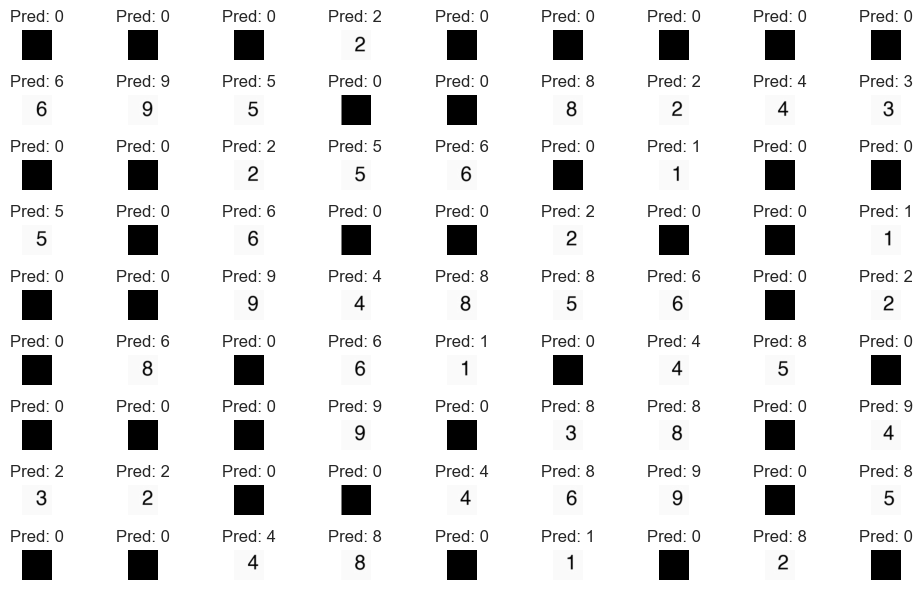

In [52]:
# 画像と予測結果を並べて表示します

# 行と列の数を設定
n_rows = 9
n_cols = 9

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6))

# サブプロットを行と列にわたってループ
for i in range(n_rows):
    for j in range(n_cols):
        idx = i * n_cols + j  # インデックスを計算
        ax = axes[i, j]  # 現在のサブプロットを取得
 
        # インデックスが画像の数以上になったら終了
        if idx >= len(cell_images):
            break

        ax.imshow(cell_images[idx], cmap='gray')
        ax.set_title(f'Pred: {predicted[idx]}')
        ax.axis('off')

plt.tight_layout()
plt.show()